# Fiscal econometrics in R: an independent check of the debt analysis

This notebook re-computes the key statistics of notebooks 1 and 2 with **R and established R packages**, starting again from the
official Eurostat files, and compares them with the Python/C++ package `public_debt`:

| Quantity | R implementation | Python notebook |
| --- | --- | --- |
| Fiscal dataset (debt, balances, interest, growth, deflator) | own parser of the Eurostat JSON-stat API | notebook 1 |
| Debt decomposition (primary deficit, interest, growth, inflation, stock-flow) | direct formulas | notebook 1 |
| Output gap | `mFilter::hpfilter` (Hodrick-Prescott, lambda = 100) | notebook 2 |
| Fiscal reaction function with Newey-West standard errors | `lm`, `sandwich::NeweyWest`, `lmtest::coeftest` | notebook 2 |
| Structural breaks in the primary balance | `strucchange::breakpoints` (Bai and Perron, 2003) | new in R |

**Requirements.** R 4.2 or later with the packages in `r/install_packages.R` and the IRkernel (see the README). The comparison cells
call the Python package if it is installed (`PYTHON` environment variable, `.venv` in the repository or `python3` on the PATH);
otherwise they are skipped. Data are downloaded into `data/raw/r/`.

In [1]:
suppressPackageStartupMessages({
  library(jsonlite)
  library(ggplot2)
  library(mFilter)
  library(sandwich)
  library(lmtest)
  library(strucchange)
})
options(width = 120, repr.plot.width = 10, repr.plot.height = 4.6, repr.plot.res = 110, scipen = 6)

# Repository root: the folder that contains scripts/public_debt.
find_root <- function() {
  d <- normalizePath(getwd())
  repeat {
    if (dir.exists(file.path(d, "scripts", "public_debt"))) return(d)
    parent <- dirname(d)
    if (parent == d) stop("run the notebook inside the repository")
    d <- parent
  }
}
ROOT <- find_root()
CACHE <- file.path(ROOT, "data", "raw", "r")   # ignored by Git
dir.create(CACHE, recursive = TRUE, showWarnings = FALSE)

cached_download <- function(url, name) {
  path <- file.path(CACHE, name)
  if (!file.exists(path)) download.file(url, path, quiet = TRUE, mode = "wb")
  path
}

# Results of the Python/C++ engine for the comparison. The code is run with the interpreter in the
# PYTHON environment variable, or .venv in the repository, or python3 on the PATH; it must print JSON.
python_json <- function(code) {
  candidates <- c(Sys.getenv("PYTHON"), file.path(ROOT, ".venv", "bin", "python"),
                  file.path(ROOT, ".venv", "Scripts", "python.exe"), Sys.which("python3"), Sys.which("python"))
  candidates <- candidates[nzchar(candidates) & file.exists(candidates)]
  if (length(candidates) == 0) { message("Python not found: comparison skipped"); return(NULL) }
  script <- tempfile(fileext = ".py")
  writeLines(c("import json, os, sys", sprintf("os.chdir(%s)", deparse(ROOT)), code), script)
  out <- suppressWarnings(system2(candidates[1], script, stdout = TRUE, stderr = FALSE))
  if (!is.null(attr(out, "status")) || length(out) == 0) {
    message("the Python package public_debt is not available: comparison skipped"); return(NULL)
  }
  fromJSON(paste(out, collapse = "\n"))
}

compare <- function(r, py, label = names(r)) {
  data.frame(quantity = label, R = signif(r, 10), Python = signif(py, 10),
             `abs. difference` = signif(abs(r - py), 3), check.names = FALSE, row.names = NULL)
}

COLORS <- c("#2a78d6", "#eb6834", "#1baf7a", "#eda100")
theme_set(theme_minimal(base_size = 12) +
          theme(panel.grid.minor = element_blank(), plot.title.position = "plot",
                plot.title = element_text(face = "bold"), legend.position = "top"))
cat(R.version.string, "| repository:", basename(ROOT), "\n")

# Eurostat dissemination API (JSON-stat 2.0), parsed into a long data frame.
eurostat <- function(dataset, ...) {
  filters <- list(...)
  query <- c("format=JSON", "lang=EN",
             unlist(Map(function(k, v) paste0(k, "=", v), rep(names(filters), lengths(filters)), unlist(filters))))
  url <- paste0("https://ec.europa.eu/eurostat/api/dissemination/statistics/1.0/data/", dataset, "?",
                paste(query, collapse = "&"))
  tag <- gsub("[^A-Za-z0-9]+", "_", paste(query[-(1:2)], collapse = "_"))
  js <- fromJSON(cached_download(url, paste0(dataset, "_", tag, ".json")), simplifyVector = FALSE)
  ids <- unlist(js$id); sizes <- unlist(js$size)
  labels <- lapply(ids, function(d) {
    idx <- js$dimension[[d]]$category$index
    if (is.null(names(idx))) unlist(idx) else names(idx)[order(unlist(idx))]
  })
  values <- js$value
  if (is.null(names(values))) {
    keep <- !vapply(values, is.null, logical(1))
    pos <- which(keep) - 1; v <- as.numeric(unlist(values[keep]))
  } else {
    pos <- as.integer(names(values)); v <- as.numeric(unlist(values))
  }
  strides <- rev(cumprod(c(1, rev(sizes)))[seq_along(sizes)])
  out <- as.data.frame(setNames(lapply(seq_along(ids), function(i) labels[[i]][(pos %/% strides[i]) %% sizes[i] + 1]), ids),
                       stringsAsFactors = FALSE)
  out$value <- v
  out$year <- as.integer(substr(out$time, 1, 4))
  out
}

R version 4.3.3 (2024-02-29) | repository: italian-public-debt 


## 1. The fiscal dataset from Eurostat

General government (S13), excessive deficit procedure definitions: gross debt (GD), net lending/borrowing (B9) and interest payable
(D41PAY) in % of GDP; GDP at current prices (CP_MEUR) and real growth (CLV_PCH_PRE). Derived: nominal growth, GDP deflator inflation,
primary balance and the effective interest rate (interest over the previous year's debt, scaled by nominal growth).

In [2]:
edp <- eurostat("gov_10dd_edpt1", geo = "IT", unit = "PC_GDP", sector = "S13")
gdp <- eurostat("nama_10_gdp", geo = "IT", na_item = "B1GQ")
pick <- function(frame, ...) {
  f <- list(...); keep <- rep(TRUE, nrow(frame))
  for (k in names(f)) keep <- keep & frame[[k]] == f[[k]]
  setNames(frame$value[keep], frame$year[keep])
}
years <- sort(as.integer(names(pick(edp, na_item = "GD"))))
it <- data.frame(year = years)
it$debt <- pick(edp, na_item = "GD")[as.character(years)] / 100
it$balance <- pick(edp, na_item = "B9")[as.character(years)] / 100
it$interest <- pick(edp, na_item = "D41PAY")[as.character(years)] / 100
nominal <- pick(gdp, unit = "CP_MEUR")[as.character(years)]
it$nominal_growth <- c(NA, nominal[-1] / nominal[-length(nominal)] - 1)
it$real_growth <- pick(gdp, unit = "CLV_PCH_PRE")[as.character(years)] / 100
it$inflation <- (1 + it$nominal_growth) / (1 + it$real_growth) - 1
it$primary_balance <- it$balance + it$interest
it$effective_rate <- it$interest * (1 + it$nominal_growth) / c(NA, it$debt[-nrow(it)])
cat(sprintf("Italy %d-%d: debt %.1f%% -> %.1f%% of GDP\n", min(years), max(years), 100 * it$debt[1], 100 * tail(it$debt, 1)))
tail(transform(it, debt = 100 * debt, primary_balance = 100 * primary_balance, effective_rate = 100 * effective_rate)[,
     c("year", "debt", "primary_balance", "effective_rate")], 6)

Italy 1995-2025: debt 119.1% -> 137.1% of GDP


,year,debt,primary_balance,effective_rate
,<int>,<dbl>,<dbl>,<dbl>
26,2020,154.4,-6.0,2.350527
27,2021,145.8,-5.5,2.429525
28,2022,138.4,-4.0,3.049498
29,2023,133.9,-3.5,2.789495
30,2024,134.7,0.5,2.993210
31,2025,137.1,0.8,2.968977


In [3]:
py <- python_json('
import numpy as np
from public_debt import accounting, data, fiscal
clean = lambda s: [None if v is None or not np.isfinite(v) else float(v) for v in s]
it = data.fiscal_dataset("IT")
gap = fiscal.output_gap((1 + it["real_growth"].fillna(0)).cumprod())
dec = accounting.debt_decomposition(it)
specs = {"full sample": {}, "pandemic dummy 2020-2021": {"dummies": {"pandemic": [2020, 2021]}},
         "pandemic and tax-credit dummies": {"dummies": {"pandemic": [2020, 2021], "tax credits": [2022, 2023]}},
         "pre-pandemic sample": {"years": (int(it.index.min()), 2019)}}
bohn = {}
for name, kw in specs.items():
    t = fiscal.fiscal_reaction(it, gap, **kw)
    bohn[name] = {"coef": clean(t["coefficient"]), "se": clean(t["std. error (Newey-West)"])}
out = {"year": [int(y) for y in it.index], "gap": clean(gap), "bohn": bohn,
       "fiscal": {c: clean(it[c]) for c in ["debt", "balance", "interest", "real_growth", "inflation", "effective_rate"]},
       "dec": {c: clean(dec[c].reindex(it.index)) for c in dec.columns}}
print(json.dumps(out))
')
if (!is.null(py)) {
  cols <- c("debt", "balance", "interest", "real_growth", "inflation", "effective_rate")
  same_years <- identical(as.integer(py$year), it$year)
  diffs <- sapply(cols, function(c) max(abs(it[[c]] - unlist(lapply(py$fiscal[[c]], function(v) if (is.null(v)) NA else v))), na.rm = TRUE))
  print(data.frame(series = cols, `max abs. difference` = signif(diffs, 3), check.names = FALSE, row.names = NULL))
  cat("Same years in R and Python:", same_years, "\n")
}

          series max abs. difference
1           debt                   0
2        balance                   0
3       interest                   0
4    real_growth                   0
5      inflation                   0
6 effective_rate                   0
Same years in R and Python: TRUE 


## 2. Debt decomposition

$d_t - d_{t-1} = -pb_t + \\underbrace{\\tfrac{d_{t-1} i_t}{1+\\gamma_t}}_{\\text{interest}} \\underbrace{- \\tfrac{d_{t-1} g_t}{1+\\gamma_t}}_{\\text{real growth}}
\\underbrace{- \\tfrac{d_{t-1}\\pi_t (1+g_t)}{1+\\gamma_t}}_{\\text{inflation}} + sfa_t$, with $1+\\gamma_t = (1+g_t)(1+\\pi_t)$; the stock-flow
adjustment is the residual. The identity holds exactly by construction, so the check is on the individual components.

In [4]:
lag_debt <- c(NA, it$debt[-nrow(it)])
one_plus_gamma <- 1 + it$nominal_growth
dec <- data.frame(year = it$year, `change in debt` = it$debt - lag_debt, `primary deficit` = -it$primary_balance,
                  interest = lag_debt * it$effective_rate / one_plus_gamma,
                  `real growth` = -lag_debt * it$real_growth / one_plus_gamma,
                  inflation = -lag_debt * it$inflation * (1 + it$real_growth) / one_plus_gamma, check.names = FALSE)
dec$`stock-flow adjustment` <- dec$`change in debt` - dec$`primary deficit` - dec$interest - dec$`real growth` - dec$inflation
periods <- list("1996-1999" = 1996:1999, "2000-2007" = 2000:2007, "2008-2013" = 2008:2013, "2014-2019" = 2014:2019,
                "2020-2021" = 2020:2021, "2022-latest" = 2022:max(it$year))
by_period <- t(sapply(periods, function(y) colSums(dec[dec$year %in% y, -1]))) * 100
round(by_period, 1)
if (!is.null(py)) {
  comp <- setdiff(names(dec), "year")
  diffs <- sapply(comp, function(c) max(abs(dec[[c]] - unlist(lapply(py$dec[[c]], function(v) if (is.null(v)) NA else v))), na.rm = TRUE))
  data.frame(component = comp, `max abs. difference (fraction of GDP)` = signif(diffs, 3), check.names = FALSE, row.names = NULL)
}

,change in debt,primary deficit,interest,real growth,inflation,stock-flow adjustment
1996-1999,-6.0,-19.9,34.3,-7.4,-22.9,9.8
2000-2007,-9.6,-16.4,40.6,-12.4,-21.4,0.0
2008-2013,28.4,-6.8,28.1,10.4,-10.3,7.1
2014-2019,2.0,-9.3,23.2,-6.4,-7.7,2.3
2020-2021,11.9,11.5,6.8,0.4,-4.1,-2.7
2022-latest,-8.7,6.2,15.5,-9.3,-18.3,-2.8


component,max abs. difference (fraction of GDP)
<chr>,<dbl>
change in debt,0.00e+00
primary deficit,0.00e+00
interest,6.94e-18
real growth,6.94e-18
inflation,3.47e-18
stock-flow adjustment,1.39e-17


## 3. Output gap with `mFilter`

Output gap, max abs. difference R vs Python: 1.91e-15 (fraction of GDP)


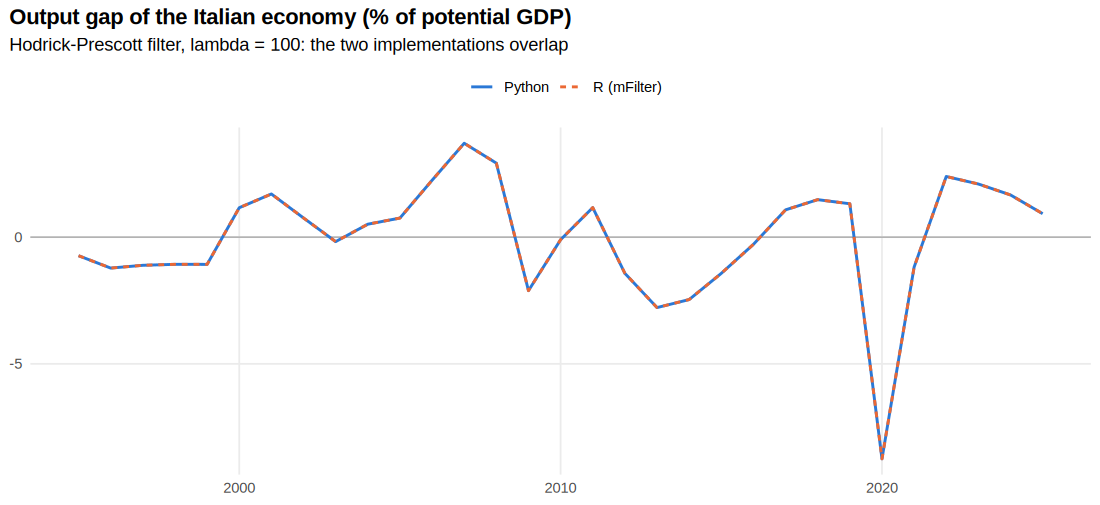

In [5]:
real_gdp <- cumprod(1 + ifelse(is.na(it$real_growth), 0, it$real_growth))
hp <- hpfilter(log(real_gdp), freq = 100, type = "lambda")
it$gap <- as.numeric(hp$cycle)
if (!is.null(py)) {
  py_gap <- unlist(lapply(py$gap, function(v) if (is.null(v)) NA else v))
  cat(sprintf("Output gap, max abs. difference R vs Python: %.2e (fraction of GDP)\n", max(abs(it$gap - py_gap))))
  ggplot(data.frame(year = rep(it$year, 2), gap = 100 * c(it$gap, py_gap), source = rep(c("R (mFilter)", "Python"), each = nrow(it))),
         aes(year, gap, colour = source, linetype = source)) +
    geom_hline(yintercept = 0, colour = "grey70") + geom_line(linewidth = 0.9) +
    scale_colour_manual(values = COLORS[1:2]) + labs(title = "Output gap of the Italian economy (% of potential GDP)",
    subtitle = "Hodrick-Prescott filter, lambda = 100: the two implementations overlap", x = NULL, y = NULL, colour = NULL, linetype = NULL)
}

## 4. Fiscal reaction function (Bohn, 1998) with Newey-West standard errors

$pb_t = a + \\rho\\, d_{t-1} + \\beta\\, \\text{gap}_t + e_t$, Bartlett-kernel Newey-West covariance with 2 lags, no prewhitening and the
$n/(n-k)$ small-sample factor, as in the Python implementation.

In [6]:
frame <- data.frame(year = it$year, pb = it$primary_balance, debt_lag = lag_debt, gap = it$gap)
frame <- frame[complete.cases(frame), ]
specs <- list("full sample" = list(data = frame, dummies = list()),
              "pandemic dummy 2020-2021" = list(data = frame, dummies = list(pandemic = 2020:2021)),
              "pandemic and tax-credit dummies" = list(data = frame, dummies = list(pandemic = 2020:2021, tax_credits = 2022:2023)),
              "pre-pandemic sample" = list(data = frame[frame$year <= 2019, ], dummies = list()))
rows <- list()
for (name in names(specs)) {
  d <- specs[[name]]$data
  for (k in names(specs[[name]]$dummies)) d[[k]] <- as.numeric(d$year %in% specs[[name]]$dummies[[k]])
  form <- as.formula(paste("pb ~ debt_lag + gap", paste(c("", names(specs[[name]]$dummies)), collapse = " + ")))
  fit <- lm(form, data = d)
  ct <- coeftest(fit, vcov. = NeweyWest(fit, lag = 2, prewhite = FALSE, adjust = TRUE))
  row <- data.frame(specification = name, rho = ct["debt_lag", 1], `s.e. (Newey-West)` = ct["debt_lag", 2],
                    `p-value` = ct["debt_lag", 4], `R^2` = summary(fit)$r.squared, n = nobs(fit), check.names = FALSE)
  if (!is.null(py)) {
    row$`rho, Python` <- py$bohn[[name]]$coef[[2]]
    row$`s.e., Python` <- py$bohn[[name]]$se[[2]]
  }
  rows[[name]] <- row
}
bohn <- do.call(rbind, rows); rownames(bohn) <- NULL
bohn

specification,rho,s.e. (Newey-West),p-value,R^2,n,"rho, Python","s.e., Python"
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<dbl>,<dbl>
full sample,-0.103750584,0.04922270,0.04447449,0.318304003,30,-0.103750584,0.04922270
pandemic dummy 2020-2021,-0.061384398,0.03720985,0.11103944,0.552485399,30,-0.061384398,0.03720985
pandemic and tax-credit dummies,-0.013950091,0.02381789,0.56332905,0.722213656,30,-0.013950091,0.02381789
pre-pandemic sample,-0.005653342,0.03270516,0.86441841,0.005980268,24,-0.005653342,0.03270516


## 5. Structural breaks in the primary balance (R only)

Bai and Perron (2003) estimate the dates at which the mean of the primary balance changes, choosing the number of breaks by BIC with
a minimum segment of 15% of the sample. This complements the Bohn regression: it shows the fiscal regimes directly.

Number of breaks selected by BIC: 2 


    regime mean primary balance (% of GDP)
 1995-2000                            4.58
 2001-2019                            1.52
 2020-2025                           -2.95


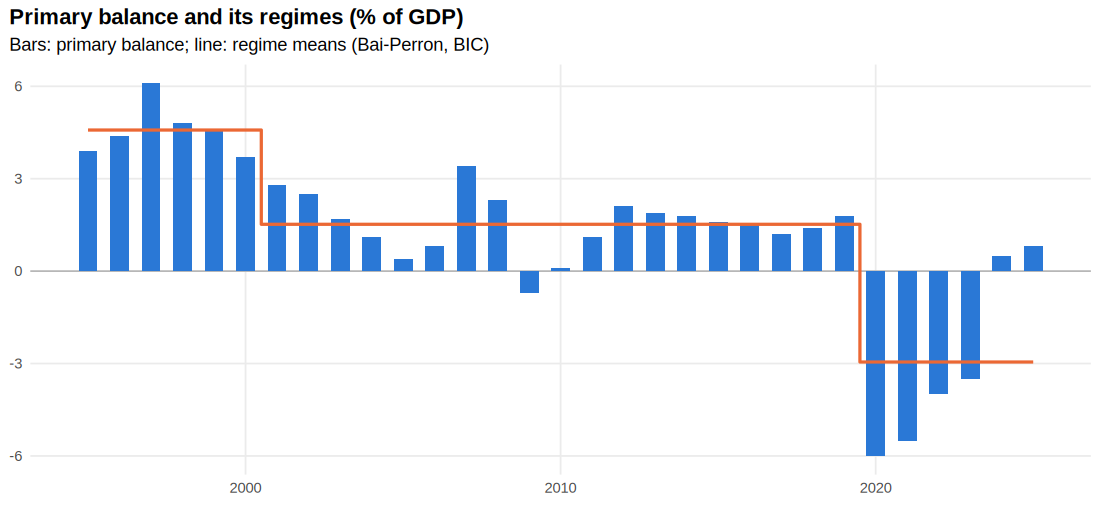

In [7]:
pb <- ts(100 * it$primary_balance, start = min(it$year))
bp <- breakpoints(pb ~ 1, h = 0.15)
n_breaks <- which.min(summary(bp)$RSS["BIC", ]) - 1
breaks <- if (n_breaks > 0) breakpoints(bp, breaks = n_breaks)$breakpoints else integer(0)
segments <- cut(seq_along(pb), c(0, breaks, length(pb)), labels = FALSE)
regimes <- aggregate(as.numeric(pb), list(segment = segments), mean)
regimes$from <- tapply(it$year, segments, min); regimes$to <- tapply(it$year, segments, max)
regimes <- data.frame(regime = paste(regimes$from, regimes$to, sep = "-"), `mean primary balance (% of GDP)` = round(regimes$x, 2),
                      check.names = FALSE)
cat("Number of breaks selected by BIC:", n_breaks, "\n")
print(regimes, row.names = FALSE)
fitted_mean <- regimes[[2]][segments]
ggplot(data.frame(year = it$year, pb = as.numeric(pb), mean = fitted_mean), aes(year)) +
  geom_hline(yintercept = 0, colour = "grey70") + geom_col(aes(y = pb), fill = COLORS[1], width = 0.6) +
  geom_step(aes(y = mean), colour = COLORS[2], linewidth = 1, direction = "mid") +
  labs(title = "Primary balance and its regimes (% of GDP)", subtitle = "Bars: primary balance; line: regime means (Bai-Perron, BIC)",
       x = NULL, y = NULL)

## 6. Conclusions

- The fiscal dataset, the decomposition, the output gap and the Newey-West regressions computed in R coincide with the Python package
  to rounding error: the notebooks' figures do not depend on the implementation.
- The structural-break analysis dates the fiscal regimes directly: the large primary surpluses of the late 1990s, the lower surpluses of
  the following two decades and the pandemic and post-pandemic deficits appear as separate regimes, consistent with the absence of a
  stable positive response of the primary balance to debt in the Bohn regressions.

### References

- Bai, J. and Perron, P. (2003). Computation and analysis of multiple structural change models. *Journal of Applied Econometrics*, 18(1), 1-22.
- Bohn, H. (1998). The behavior of U.S. public debt and deficits. *Quarterly Journal of Economics*, 113(3), 949-963.
- Newey, W. K. and West, K. D. (1987). A simple, positive semi-definite, heteroskedasticity and autocorrelation consistent covariance matrix. *Econometrica*, 55(3), 703-708.
- Zeileis, A. (2004). Econometric computing with HC and HAC covariance matrix estimators. *Journal of Statistical Software*, 11(10).
- Zeileis, A., Leisch, F., Hornik, K. and Kleiber, C. (2002). strucchange: an R package for testing for structural change. *Journal of Statistical Software*, 7(2).